In [1]:
import torch
import torch.nn as nn
import numpy as np
import cv2
from PIL import Image
import glob
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset,DataLoader,random_split
import torch.nn.functional as F

/home/ubuntu/DuyPham/.venv/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


# Define Dataset Class and DataLoader

In [2]:
class CustomDataset(Dataset):
    def __init__(self,img_paths,mask_paths,img_transforms=None):
        super().__init__()
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.img_transforms = img_transforms
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, index):
        img_path  = self.img_paths[index]
        mask_path = self.mask_paths[index]
        img  = np.array(Image.open(img_path).convert('L').convert('RGB'),dtype=np.uint8)
        mask = (np.array(Image.open(mask_path),dtype=np.uint8)[:,:,0]/255).astype(np.uint8)
        if self.img_transforms is not None:
            transform =  self.img_transforms(image = img,mask=mask)
            t_image  = transform['image']
            t_mask =  transform['mask']
        else:
            raise Exception('Transforms is compulsory')
        
        return {
            'image':t_image,
            'mask':t_mask,
        }

**Split to train test**

In [3]:
train_image_paths =  sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original/*png'))
test_image_paths =   sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Original/*png'))

train_mask_paths = sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth/*png'))
test_mask_paths =  sorted(glob.glob('/home/ubuntu/DuyPham/five/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/test/Ground truth/*png'))

**Define train_set and train_image_transforms**

In [4]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_image_transforms = A.Compose(
    [
        A.Resize(256, 256, interpolation=cv2.INTER_AREA),  
        A.Normalize(mean=(0.5,0.5,0.5,), std=(0.5,0.5,0.5,)),
        ToTensorV2(),  
    ],
    # additional_targets={'sobel': 'image', 'image': 'image', 'mask': 'mask'}
)

In [5]:
def decode(img):
    clone_img = img.clone().squeeze().detach().cpu()
    if len(clone_img.shape) > 2:
        clone_img=clone_img.permute(1,2,0).numpy()
    else:
        clone_img=clone_img.numpy()
    clone_img=clone_img*0.5+0.5
    return (clone_img*255).astype(np.uint8)


In [6]:

all_train_set=CustomDataset(train_image_paths,train_mask_paths,train_image_transforms)
train_set,val_set=random_split(all_train_set,[0.75,0.25],generator=torch.Generator().manual_seed(42))

In [7]:
test_set = CustomDataset(test_image_paths,test_mask_paths,train_image_transforms)

In [8]:
batch_size = 32
train_loader = DataLoader(train_set,batch_size,shuffle=True,num_workers=6,generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_set,batch_size,shuffle=True,num_workers=6,generator=torch.Generator().manual_seed(42))
test_loader = DataLoader(test_set,batch_size,shuffle=False)

# Define Model

## Unet

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channel, out_channel, mid_channel=None):
        super().__init__()
        if not mid_channel:
            mid_channel = out_channel

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channel, mid_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(mid_channel),
            nn.ReLU(),
            nn.Conv2d(mid_channel, out_channel, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU()
        )

    def forward(self, x):
        return self.double_conv(x)

class DownSampling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.downscaling = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channel, out_channel)
        )

    def forward(self, x):
        return self.downscaling(x)

class UpSampling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()

        self.upscaling = nn.ConvTranspose2d(in_channel, in_channel // 2, kernel_size=2, stride=2)
        self.double_conv = DoubleConv(in_channel, out_channel)

    def forward(self, x1, x2): # x1 from ConvTransposed, x2 from Encoder
        x1 = self.upscaling(x1)

        delta_height = x2.size()[2] - x1.size()[2]
        delta_width = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [delta_width // 2, delta_width - delta_width // 2,
                        delta_height // 2, delta_height - delta_height // 2])

        x = torch.cat([x2, x1], dim=1)

        return self.double_conv(x)


class OutConv(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

In [10]:
class UNETModel(nn.Module):
    def __init__(self, n_channel, n_class):
        super().__init__()
        self.n_channel = n_channel
        self.n_class = n_class

        self.first_conv = DoubleConv(n_channel, 64)
        
        self.down1 = DownSampling(64, 128)
        self.down2 = DownSampling(128, 256)
        self.down3 = DownSampling(256, 512)
        self.up2 = UpSampling(512, 256)
        self.up3 = UpSampling(256, 128)
        self.up4 = UpSampling(128, 64)

        self.final_conv = OutConv(64, n_class)

    def forward(self, x):
        x1 = self.first_conv(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x = self.up2(x4, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        return self.final_conv(x)

In [11]:
from torchinfo import summary

In [12]:
summary(UNETModel(3,1),input_data=(torch.rand(1,3,512,512)))

Layer (type:depth-idx)                        Output Shape              Param #
UNETModel                                     [1, 1, 512, 512]          --
├─DoubleConv: 1-1                             [1, 64, 512, 512]         --
│    └─Sequential: 2-1                        [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-1                       [1, 64, 512, 512]         1,792
│    │    └─BatchNorm2d: 3-2                  [1, 64, 512, 512]         128
│    │    └─ReLU: 3-3                         [1, 64, 512, 512]         --
│    │    └─Conv2d: 3-4                       [1, 64, 512, 512]         36,928
│    │    └─BatchNorm2d: 3-5                  [1, 64, 512, 512]         128
│    │    └─ReLU: 3-6                         [1, 64, 512, 512]         --
├─DownSampling: 1-2                           [1, 128, 256, 256]        --
│    └─Sequential: 2-2                        [1, 128, 256, 256]        --
│    │    └─MaxPool2d: 3-7                    [1, 64, 256, 256]         --
│    │    └

In [13]:
# from torchinfo import summary
# from thop import profile
# # from CustomNET import CustomNET
# flops, params = profile(CustomNET(3,1), inputs=(torch.rand(1,3,960,960),torch.rand(1,3,960,960)),verbose=False)
# print(summary(CustomNET(3,1),input_data=(torch.rand(1,3,960,960),torch.rand(1,3,960,960))))

# print(flops,params)

In [14]:
import math
def plot(segmodel,sample,device):
    model = segmodel
    with torch.no_grad():
        model = model.to(device)
        model.eval()
        image,mask=sample.values()
        fig,ax = plt.subplots(1,3,figsize=(12,8))
        pred_mask = model(image.unsqueeze(0).to(device))
        ax[0].imshow(decode(image),cmap='gray')
        ax[0].axis(False)
        ax[0].set_title('Image',c='black')

        ax[1].imshow(mask.cpu())
        ax[1].axis(False)
        ax[1].set_title('True mask',c='black')


        ax[2].imshow(torch.where(pred_mask>0.5,1,0).squeeze().detach().cpu())
        ax[2].axis(False)
        ax[2].set_title('Pred Mask',c='green')
        plt.show()

In [15]:
device = 'cuda:1' if torch.cuda.is_available() else 'cpu'

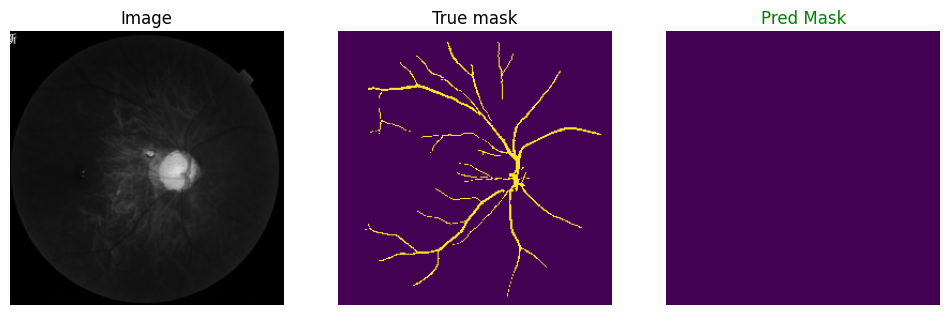

In [16]:
plot(nn.Sequential(UNETModel(3,1),nn.Sigmoid()),test_set[1],device)

## UNet PP

In [ ]:
class DoubleConvolution(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels=None):
        super().__init__()
        if not mid_channels:
            mid_channels = out_channels

        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(mid_channels),
            nn.Conv2d(mid_channels, out_channels, kernel_size=3, padding='same'),
            nn.BatchNorm2d(out_channels),
            nn.Mish()
        )

    def forward(self, x):
        return self.double_conv(x)


class OutConvolution(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.conv = nn.Conv2d(in_channel, out_channel, kernel_size=1)

    def forward(self, x):
        return self.conv(x)


class DownScaling(nn.Module):
    def __init__(self, in_channel, out_channel):
        super().__init__()
        self.downscaling = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConvolution(in_channel, out_channel)
        )

    def forward(self, x):
        return self.downscaling(x)


class UpScaling(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2),
            nn.Mish()
        )
    def forward(self, x):
        return self.up(x)


class Concat_and_Conv_Layer(nn.Module):
    def __init__(self, in_channels, out_channels, dim=1):
        super().__init__()
        self.dim = dim
        self.conv = DoubleConvolution(in_channels, out_channels)

    def forward(self, *inputs):
        conv_input = torch.cat(inputs, dim=self.dim)
        output = self.conv(conv_input)
        return output

In [18]:
class UNET_PP(nn.Module):
    def __init__(self, n_channels, n_classes):
        super().__init__()

        self.n_channels = n_channels
        self.n_classes = n_classes

        # Backbone
        self.down_00 = DoubleConvolution(self.n_channels, 64)             # Output: 64 channels
        self.down_10 = DownScaling(64, 128)                                 # Output: 128 channels, resolution halved
        self.up_10   = UpScaling(128, 64)                                   # Up: 128 -> 64
        self.down_20 = DownScaling(128, 256)                                # Output: 256 channels
        self.up_20   = UpScaling(256, 128)                                  # Up: 256 -> 128
        self.down_30 = DownScaling(256, 512)                                # Output: 512 channels
        self.up_30   = UpScaling(512, 256)                                  # Up: 512 -> 256
        self.down_40 = DownScaling(512, 1024)                               # Output: 1024 channels
        self.up_40   = UpScaling(1024, 512)                                 # Up: 1024 -> 512

        # First Dense Layer
        self.cat_01 = Concat_and_Conv_Layer(64*2, 64)                       # 64+64 = 128 -> 64
        self.cat_11 = Concat_and_Conv_Layer(128*2, 128)                     # 128+128 = 256 -> 128
        self.cat_21 = Concat_and_Conv_Layer(256*2, 256)                     # 256+256 = 512 -> 256

        # Second Dense Layer
        self.cat_02 = Concat_and_Conv_Layer(64*2 + 64, 128)                 # x_00 (64), x_01 (64), up_11(x_11) (64) = 192 -> 128
        self.up_11  = UpScaling(128, 64)                                    # Up: 128 -> 64
        self.cat_12 = Concat_and_Conv_Layer(128*2 + 128, 256)               # x_10 (128), x_11 (128), up_21(x_21) (128) = 384 -> 256
        self.up_21  = UpScaling(256, 128)                                   # Up: 256 -> 128

        # Third Dense Layer
        self.cat_03 = Concat_and_Conv_Layer(320, 512)                       # x_00 (64) + x_01 (64) + x_02 (128) + up_12(x_12) (64) = 320 channels
        self.up_12  = UpScaling(256, 64)                                    # Up: 256 -> 64

        # Last Layer
        self.cat_31 = Concat_and_Conv_Layer(512*2, 512)                     # x_30 (512) + up_40(x_40) (512) = 1024 -> 512
        self.up_31  = UpScaling(512, 256)                                   # Up: 512 -> 256
        self.cat_22 = Concat_and_Conv_Layer(256*3, 256)                     # x_20 (256) + x_21 (256) + up_31(x_31) (256) = 768 -> 256
        self.cat_13 = Concat_and_Conv_Layer(128*3 + 256, 128)               # x_10 (128) + x_11 (128) + x_12 (256) + up_22(x_22) (128) = 640 -> 128
        self.up_22  = UpScaling(256, 128)                                   # Up: 256 -> 128
        self.cat_04 = Concat_and_Conv_Layer(64*3 + 128 + 512, 64)           # x_00 (64) + x_01 (64) + x_02 (128) + x_03 (512) + up_13(x_13) (64) = 832 -> 64
        self.up_13  = UpScaling(128, 64)                                    # Up: 128 -> 64

        # Output
        self.output_conv = OutConvolution(64, self.n_classes)

    def forward(self, x):
        # Backbone forward
        x_00 = self.down_00(x)         # [B, 64, H, W]
        x_10 = self.down_10(x_00)      # [B, 128, H/2, W/2]
        x_20 = self.down_20(x_10)      # [B, 256, H/4, W/4]
        x_30 = self.down_30(x_20)      # [B, 512, H/8, W/8]
        x_40 = self.down_40(x_30)      # [B, 1024, H/16, W/16]

        # First Dense Layer
        x_01 = self.cat_01(x_00, self.up_10(x_10))      # [B, 64, H, W]
        x_11 = self.cat_11(x_10, self.up_20(x_20))        # [B, 128, H/2, W/2]
        x_21 = self.cat_21(x_20, self.up_30(x_30))        # [B, 256, H/4, W/4]

        # Second Dense Layer
        x_02 = self.cat_02(x_00, x_01, self.up_11(x_11))  # [B, 128, H, W]
        x_12 = self.cat_12(x_10, x_11, self.up_21(x_21))  # [B, 256, H/2, W/2]

        # Third Dense Layer
        x_03 = self.cat_03(x_00, x_01, x_02, self.up_12(x_12))  # [B, 512, H, W]

        # Last Layer
        x_31 = self.cat_31(x_30, self.up_40(x_40))              # [B, 512, H/8, W/8]
        x_22 = self.cat_22(x_20, x_21, self.up_31(x_31))         # [B, 256, H/4, W/4]
        x_13 = self.cat_13(x_10, x_11, x_12, self.up_22(x_22))   # [B, 128, H/2, W/2]
        x_04 = self.cat_04(x_00, x_01, x_02, x_03, self.up_13(x_13))  # [B, 64, H, W]

        # Output
        output = self.output_conv(x_04)
        return output

# Train

## Unet

**Define Loss**

In [19]:
class CustomSegLoss(nn.Module):
    def __init__(self,alpha=1):
        super().__init__()
        self.alpha=alpha
    def forward(self,pred,truth):
        
        pred=pred.squeeze()
        truth=truth.squeeze()
        # bce Loss
        # bce = nn.BCELoss()(pred,truth.type(torch.float32))

        # Abe Dice Loss

        erc = torch.pow(pred,2*(1-(pred**2)))
        abe_diceloss_all = 1-(torch.sum(2*erc*truth)/torch.sum(erc**2 +truth))
        return self.alpha*abe_diceloss_all

In [20]:
# unet_model =nn.Sequential(UNETModel(3,1),nn.Sigmoid()).to(device)

# unet_model = nn.DataParallel(unet_model,device_ids=[1,2,3,0]) 

In [21]:
model =nn.Sequential(UNETModel(3,1),nn.Sigmoid()).to(device)
model = nn.DataParallel(model,device_ids=[1,2,3,0]) 

In [22]:
from torch.optim import Adam
optimizer =Adam(model.parameters(),lr=2e-4,weight_decay=1e-5)
criterion =CustomSegLoss()

In [23]:
from torchmetrics.classification import BinaryF1Score,AUROC, Recall, Specificity,JaccardIndex
def eval_for_seg(model,val_loader,device):
    with torch.no_grad():
        model.eval()
        truth_label=[]
        pred_label=[]
        for sample in val_loader:
            image,mask=sample.values()
            
            image=image.to(device)
            mask=mask.to(device)
            pred_mask = torch.where(model(image)>0.5,1,0).cpu().flatten()
            truth_label.extend(mask.flatten().tolist())
            pred_label.extend(pred_mask.detach().numpy().tolist())
        truth_label=torch.tensor(truth_label).to(device)
        pred_label= torch.tensor(pred_label).to(device)
        return BinaryF1Score().to(device)(pred_label,truth_label).item(),\
            Recall(task='binary').to(device)(pred_label,truth_label).item(),\
            Specificity(task='binary').to(device)(pred_label,truth_label).item(),\
            AUROC(task='binary').to(device)(pred_label,truth_label).item(),\
            JaccardIndex(task='binary').to(device)(pred_label,truth_label).item()

In [24]:
from tqdm import tqdm
def train_one_epoch_for_seg(model,train_loader,optimizer,criterion,device):
    model.train()
    training_loss = 0 
    for sample in tqdm(train_loader):
        image,mask=sample.values()
        image=image.to(device)
        mask=mask.to(device)

        pred_mask = model(image)

        loss = criterion(pred_mask,mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        training_loss+=loss.item()
    return training_loss/len(train_loader)


In [ ]:
def train_seg(epochs,model,train_loader,val_loader,optimizer,criterion,device,save_dir='./best_seg_model.pth'):
    best_val_f1=0
    lst_f1=[]
    lst_loss=[]
    lst_recall=[]
    lst_spe=[]
    lst_auc=[]
    lst_iou=[]
    for e in tqdm(range(epochs)):
        training_loss=train_one_epoch_for_seg(model,train_loader,optimizer,criterion,device)
        val_f1, val_recall, val_specificity, val_auroc,iou = eval_for_seg(model,val_loader,device)
        print(f'Epoch [{e}/{epochs}]: training loss {training_loss} val f1 {val_f1} val recall {val_recall} val specificity {val_specificity} val auroc {val_auroc} val iou {iou}')
        if best_val_f1 < val_f1:
            best_val_f1=val_f1
            if isinstance(model,nn.DataParallel):
                torch.save(model.module.state_dict(), save_dir)
            else:
                torch.save(model.state_dict(), save_dir)
            print('===>Save model')
        if e%10==0:
            print(training_loss)
            plot(model,test_set[0],device)
        lst_f1.append(val_f1)
        lst_loss.append(training_loss)
        lst_recall.append(val_recall)
        lst_spe.append(val_specificity)
        lst_auc.append(val_auroc)
        lst_iou.append(iou)
    return {
        'f1':lst_f1,
        'loss':lst_loss,
        'recall':lst_recall,
        'spe':lst_spe,
        'auc':lst_auc,
        'iou':lst_iou,

    }

100%|██████████| 15/15 [00:15<00:00,  1.06s/it]


Epoch [0/40]: training loss 0.5471373160680135 val f1 0.25785407423973083 val recall 0.4924851953983307 val specificity 0.8076238036155701 val auroc 0.6500544548034668 val iou 0.14800944924354553
===>Save model
0.5471373160680135


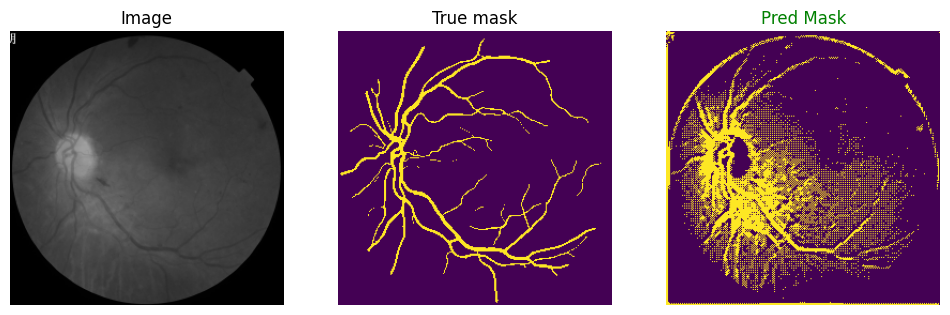

  5%|▌         | 2/40 [00:48<15:19, 24.19s/it]

Epoch [1/40]: training loss 0.3679506500562032 val f1 0.252074271440506 val recall 0.18960720300674438 val specificity 0.973982036113739 val auroc 0.5817946195602417 val iou 0.14421337842941284


  8%|▊         | 3/40 [01:10<14:22, 23.31s/it]

Epoch [2/40]: training loss 0.2997612794240316 val f1 0.5727267861366272 val recall 0.5759833455085754 val specificity 0.9640118479728699 val auroc 0.7699975967407227 val iou 0.40127336978912354
===>Save model


 10%|█         | 4/40 [01:33<13:48, 23.01s/it]

...

Epoch [8/40]: training loss 0.17998433510462444 val f1 0.6990635991096497 val recall 0.8747162222862244 val specificity 0.9481059312820435 val auroc 0.9114111065864563 val iou 0.5373541116714478


 25%|██▌       | 10/40 [03:54<11:51, 23.71s/it]

Epoch [9/40]: training loss 0.16900781393051148 val f1 0.8035585880279541 val recall 0.8430368304252625 val specificity 0.9789040088653564 val auroc 0.9109704494476318 val iou 0.6716238260269165
===>Save model


100%|██████████| 15/15 [00:14<00:00,  1.06it/s]


Epoch [10/40]: training loss 0.16121647755304971 val f1 0.6393488049507141 val recall 0.917489230632782 val specificity 0.921261727809906 val auroc 0.9193755388259888 val iou 0.4698844254016876
0.16121647755304971


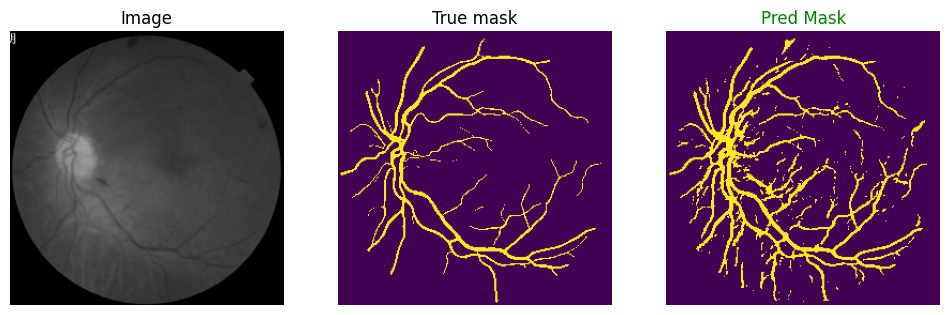

 30%|███       | 12/40 [04:37<10:37, 22.77s/it]

Epoch [11/40]: training loss 0.16728254159291586 val f1 0.8043311238288879 val recall 0.833530068397522 val specificity 0.9802387356758118 val auroc 0.9068844318389893 val iou 0.6727039217948914
===>Save model


 32%|███▎      | 13/40 [04:59<10:07, 22.49s/it]

Epoch [12/40]: training loss 0.15330888430277506 val f1 0.8175286054611206 val recall 0.8416284918785095 val specificity 0.9820361137390137 val auroc 0.911832332611084 val iou 0.6913728713989258
===>Save model


 35%|███▌      | 14/40 [05:22<09:43, 22.44s/it]

...

Epoch [18/40]: training loss 0.12298956712086996 val f1 0.840187132358551 val recall 0.8699248433113098 val specificity 0.9833971261978149 val auroc 0.92666095495224 val iou 0.7244161367416382
===>Save model


 50%|█████     | 20/40 [07:38<07:40, 23.05s/it]

Epoch [19/40]: training loss 0.12181781530380249 val f1 0.8487961888313293 val recall 0.8450527787208557 val specificity 0.9879215359687805 val auroc 0.9164870977401733 val iou 0.737311840057373
===>Save model


100%|██████████| 15/15 [00:16<00:00,  1.07s/it]


Epoch [20/40]: training loss 0.11961202621459961 val f1 0.8416743874549866 val recall 0.8836739659309387 val specificity 0.982135534286499 val auroc 0.9329046607017517 val iou 0.7266302108764648
0.11961202621459961


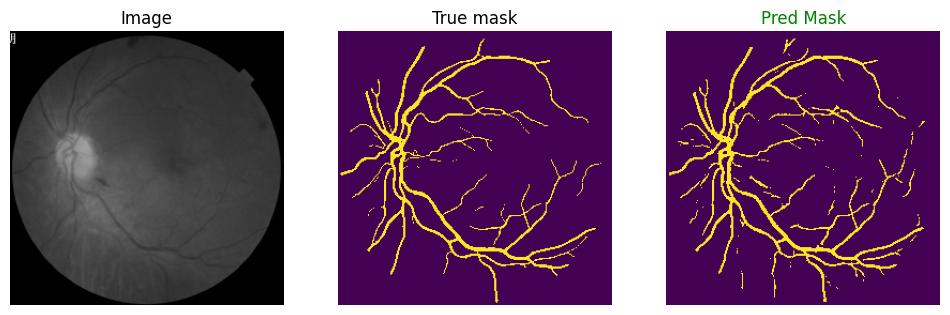

 55%|█████▌    | 22/40 [08:27<07:06, 23.69s/it]

Epoch [21/40]: training loss 0.1230371634165446 val f1 0.8259022831916809 val recall 0.7670028805732727 val specificity 0.9925305247306824 val auroc 0.8797666430473328 val iou 0.7034357190132141


 57%|█████▊    | 23/40 [08:51<06:44, 23.81s/it]

Epoch [22/40]: training loss 0.135992964108785 val f1 0.7921612858772278 val recall 0.909801185131073 val specificity 0.9679942727088928 val auroc 0.9388977289199829 val iou 0.6558501720428467


 60%|██████    | 24/40 [09:15<06:22, 23.88s/it]

...

Epoch [28/40]: training loss 0.10993566513061523 val f1 0.8464877605438232 val recall 0.8845493793487549 val specificity 0.9830238819122314 val auroc 0.9337866306304932 val iou 0.7338351011276245


 75%|███████▌  | 30/40 [11:40<04:01, 24.18s/it]

Epoch [29/40]: training loss 0.1045505166053772 val f1 0.8502363562583923 val recall 0.8877698183059692 val specificity 0.9834255576133728 val auroc 0.9355976581573486 val iou 0.7394879460334778


100%|██████████| 15/15 [00:15<00:00,  1.07s/it]


Epoch [30/40]: training loss 0.10068897008895875 val f1 0.8629271984100342 val recall 0.8708255887031555 val specificity 0.9878096580505371 val auroc 0.9293175935745239 val iou 0.7589023113250732
===>Save model
0.10068897008895875


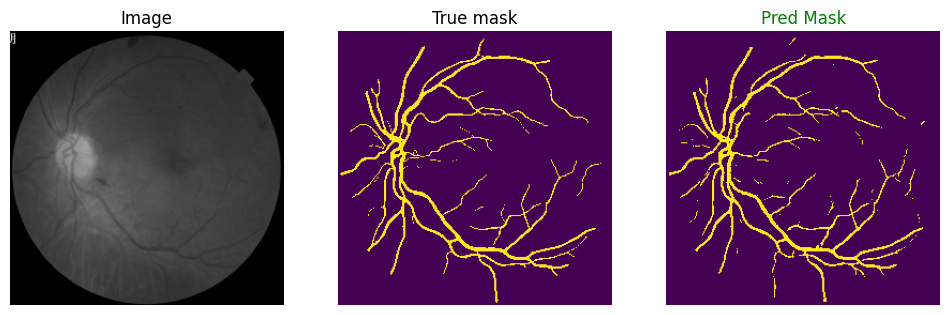

 80%|████████  | 32/40 [12:29<03:14, 24.25s/it]

Epoch [31/40]: training loss 0.09738947550455729 val f1 0.8632713556289673 val recall 0.8650962114334106 val specificity 0.9884997606277466 val auroc 0.9267979860305786 val iou 0.7594348788261414
===>Save model


 82%|████████▎ | 33/40 [12:53<02:49, 24.16s/it]

Epoch [32/40]: training loss 0.09403615792592367 val f1 0.8624638319015503 val recall 0.8776234984397888 val specificity 0.9869788885116577 val auroc 0.9323012232780457 val iou 0.7581859230995178


 85%|████████▌ | 34/40 [13:17<02:25, 24.25s/it]

...

Epoch [37/40]: training loss 0.08389915227890014 val f1 0.862956166267395 val recall 0.8729560971260071 val specificity 0.9875832200050354 val auroc 0.9302696585655212 val iou 0.7589471340179443


 98%|█████████▊| 39/40 [15:19<00:24, 24.23s/it]

Epoch [38/40]: training loss 0.08208682139714558 val f1 0.8565887808799744 val recall 0.8813276290893555 val specificity 0.9854164123535156 val auroc 0.9333720207214355 val iou 0.7491520047187805


100%|██████████| 40/40 [15:43<00:00, 23.58s/it]

Epoch [39/40]: training loss 0.08163183530171712 val f1 0.8642921447753906 val recall 0.8673812747001648 val specificity 0.9884471893310547 val auroc 0.9279142618179321 val iou 0.7610162496566772


In [26]:
history=train_seg(40,model,train_loader,val_loader,optimizer,criterion,device)

In [27]:
import time
torch.cuda.empty_cache()
time.sleep(5)

In [39]:
import seaborn as sns
import pandas as pd
def plot_history(history):
    long_data = []
    for label, y_values in history.items():
        for x, y in enumerate(y_values):
            if label=='iot':label='iou'
            long_data.append({'label': label, 'x': x, 'y': y})

    df = pd.DataFrame(long_data)


    sns.lineplot(data=df, x='x', y='y', hue='label')
    plt.grid()
    plt.xlabel('Epochs')
    plt.ylabel('Value')
    plt.title('Plot metrics in training process')
    plt.show()

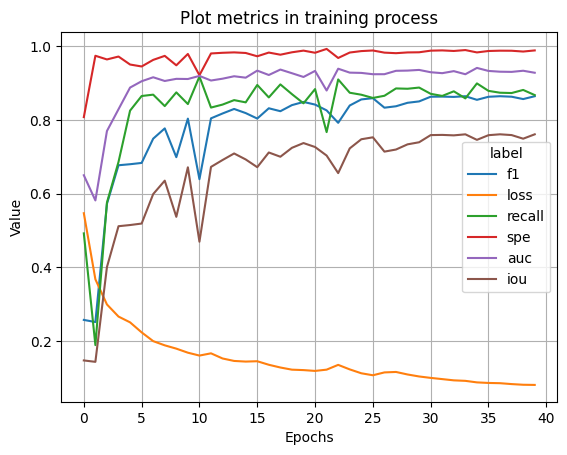

In [40]:
plot_history(history)

## UNET PP

In [36]:
unet_pp =nn.Sequential(UNET_PP(3,1),nn.Sigmoid()).to(device)
unet_pp = nn.DataParallel(unet_pp,device_ids=[1,2,3,0]) 

In [37]:
optimizer_pp =Adam(unet_pp.parameters(),lr=3e-4,weight_decay=1e-5)
criterion_pp =CustomSegLoss()

100%|██████████| 15/15 [00:15<00:00,  1.03s/it]


Epoch [0/30]: training loss 0.49182801246643065 val f1 0.001144750858657062 val recall 0.0011418749345466495 val specificity 0.9178522229194641 val auroc 0.4594970643520355 val iou 0.0005727032548747957
===>Save model
0.49182801246643065


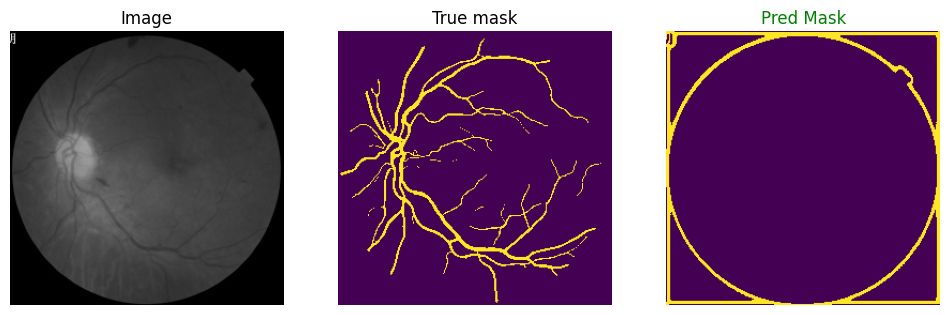

100%|██████████| 15/15 [00:15<00:00,  1.03s/it]


Epoch [1/30]: training loss 0.3403544068336487 val f1 0.17839086055755615 val recall 0.18260273337364197 val specificity 0.9285328388214111 val auroc 0.5555678009986877 val iou 0.09793037921190262


  7%|▋         | 2/30 [00:48<11:16, 24.15s/it]

===>Save model


100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


...

Epoch [8/30]: training loss 0.1784070650736491 val f1 0.7702233195304871 val recall 0.8412221074104309 val specificity 0.9716371893882751 val auroc 0.9064295887947083 val iou 0.6263115406036377


 33%|███▎      | 10/30 [03:59<07:53, 23.69s/it]

Epoch [9/30]: training loss 0.17913555701573688 val f1 0.7661328315734863 val recall 0.824233889579773 val specificity 0.9729346632957458 val auroc 0.898584246635437 val iou 0.6209200024604797


100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


Epoch [10/30]: training loss 0.1583804488182068 val f1 0.8024774193763733 val recall 0.8320191502571106 val specificity 0.9800293445587158 val auroc 0.9060242176055908 val iou 0.6701146364212036
===>Save model
0.1583804488182068


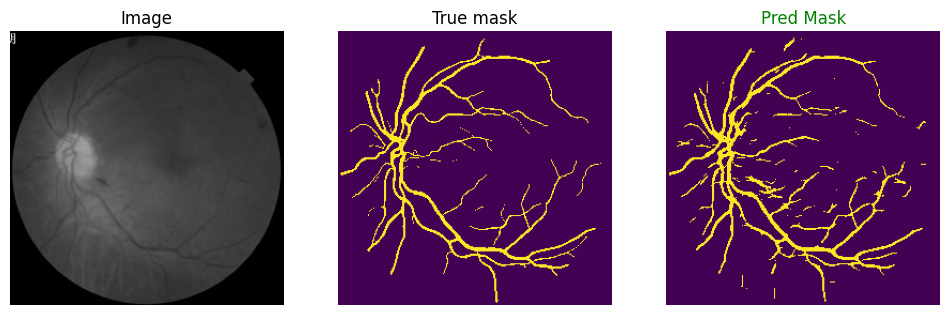

100%|██████████| 15/15 [00:15<00:00,  1.04s/it]


Epoch [11/30]: training loss 0.15041237274805705 val f1 0.8134093284606934 val recall 0.820539116859436 val specificity 0.9837172031402588 val auroc 0.9021282196044922 val iou 0.685501217842102


 40%|████      | 12/30 [04:47<07:11, 24.00s/it]

===>Save model


100%|██████████| 15/15 [00:15<00:00,  1.04s/it]


...

Epoch [19/30]: training loss 0.11595395803451539 val f1 0.8569980263710022 val recall 0.8302017450332642 val specificity 0.9911339282989502 val auroc 0.910667896270752 val iou 0.7497782707214355


 67%|██████▋   | 20/30 [07:59<04:00, 24.01s/it]

===>Save model


100%|██████████| 15/15 [00:15<00:00,  1.03s/it]


Epoch [20/30]: training loss 0.11552583773930868 val f1 0.8618550896644592 val recall 0.8559238910675049 val specificity 0.9892287254333496 val auroc 0.9225763082504272 val iou 0.7572454810142517
===>Save model
0.11552583773930868


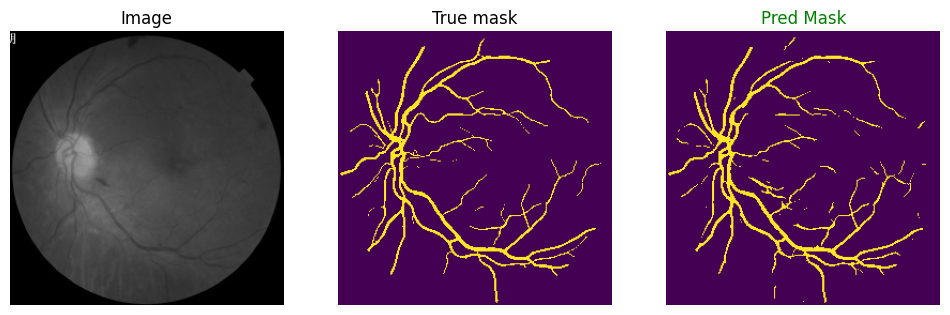

 73%|███████▎  | 22/30 [08:47<03:11, 23.99s/it]

Epoch [21/30]: training loss 0.11361864805221558 val f1 0.8546638488769531 val recall 0.8422001004219055 val specificity 0.9893674850463867 val auroc 0.9157837629318237 val iou 0.7462121844291687


 77%|███████▋  | 23/30 [09:11<02:47, 23.96s/it]

Epoch [22/30]: training loss 0.11605024735132853 val f1 0.8311756253242493 val recall 0.8790358901023865 val specificity 0.9804823398590088 val auroc 0.92975914478302 val iou 0.7111210227012634


 80%|████████  | 24/30 [09:35<02:23, 23.87s/it]

...

===>Save model


100%|██████████| 15/15 [00:15<00:00,  1.02s/it]


Epoch [29/30]: training loss 0.10439460277557373 val f1 0.8740954399108887 val recall 0.8831756711006165 val specificity 0.9886263012886047 val auroc 0.9359009265899658 val iou 0.7763494849205017


100%|██████████| 30/30 [11:58<00:00, 23.97s/it]

===>Save model


In [38]:
history_1=train_seg(30,unet_pp,train_loader,val_loader,optimizer_pp,criterion_pp,device,'./best_seg_model_pp.pth')

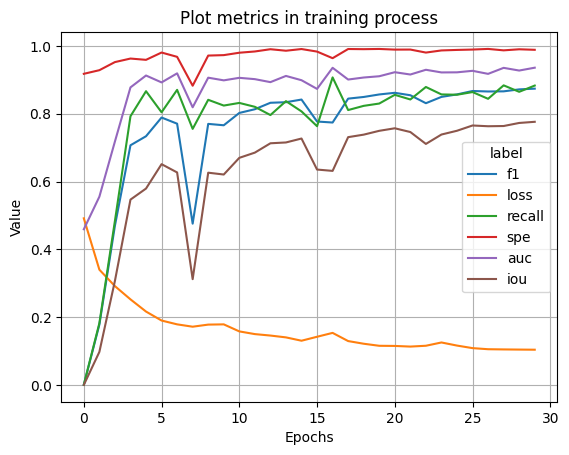

In [41]:
plot_history(history_1)

# Evaluate

## UNET

**Eval**

In [42]:
best_model=nn.Sequential(UNETModel(3,1),nn.Sigmoid())
best_model.load_state_dict(torch.load('/home/ubuntu/DuyPham/test_vton_1/notebooks/Duy/best_seg_model.pth',weights_only=True))
best_model.to(device)
best_model=nn.DataParallel(best_model,device_ids=[1,2,3,0])

**Show Random 5 train_image**

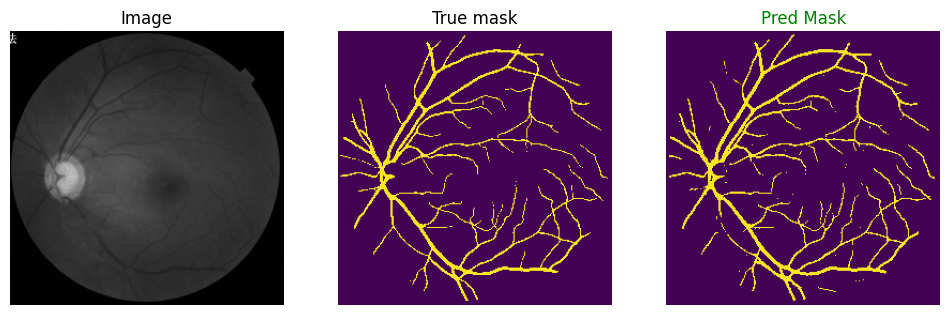

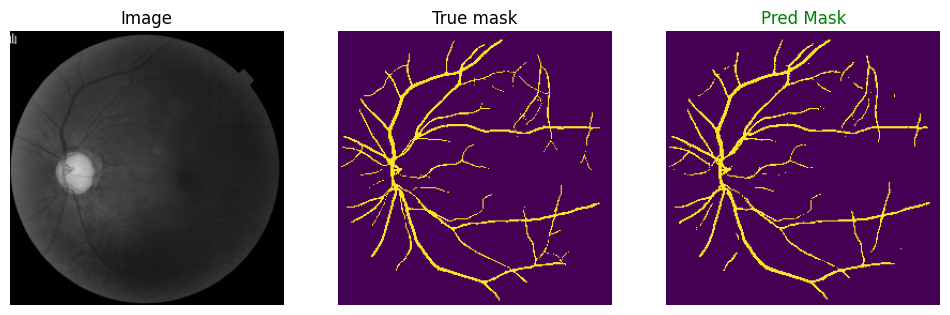

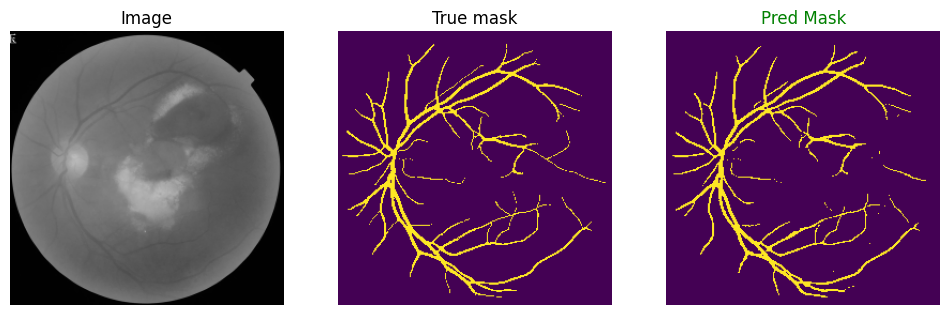

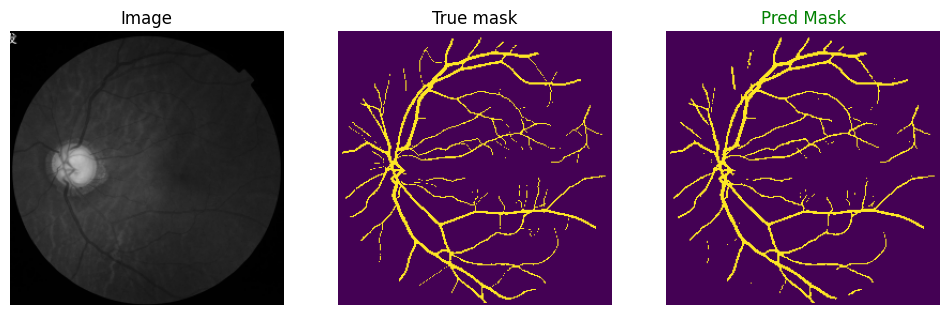

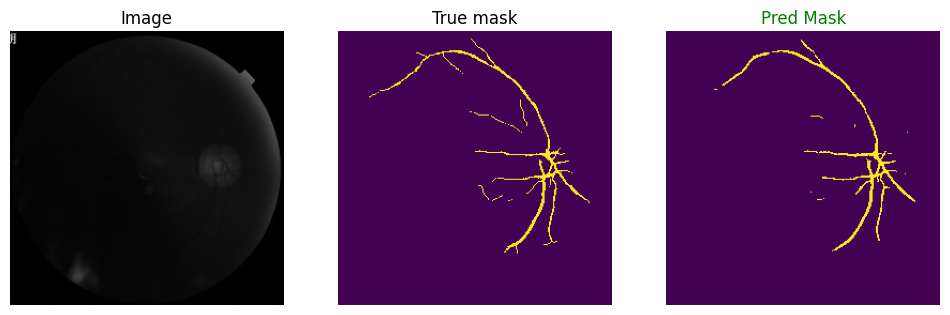

In [43]:
for i in range(5):
    plot(best_model,train_set[np.random.randint(0,len(test_set))],device)

**Show Random 5 test_image**

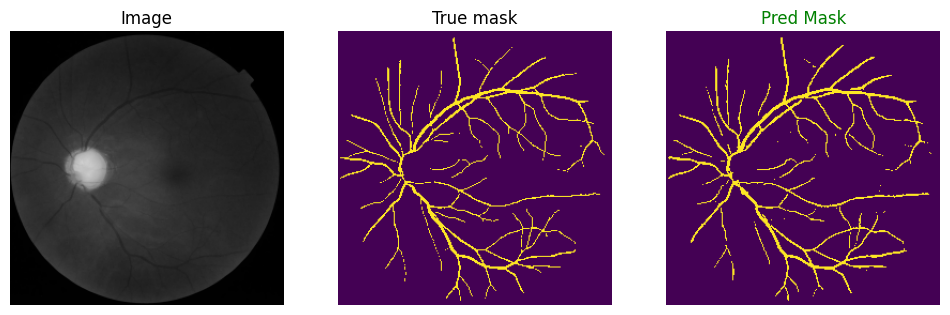

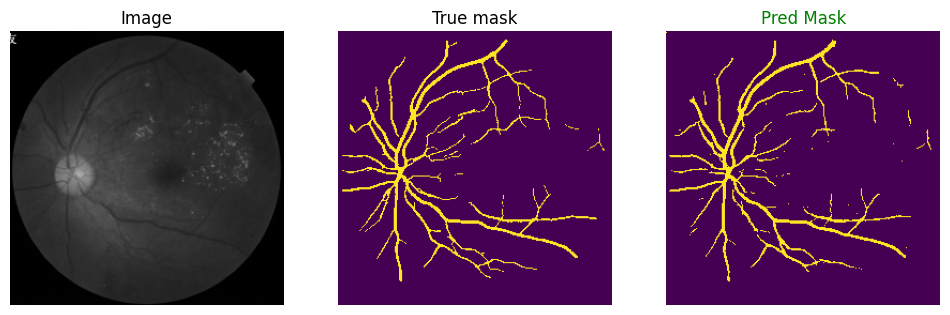

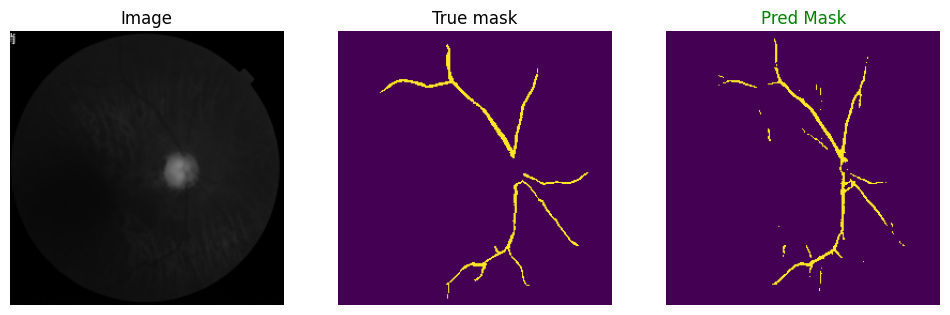

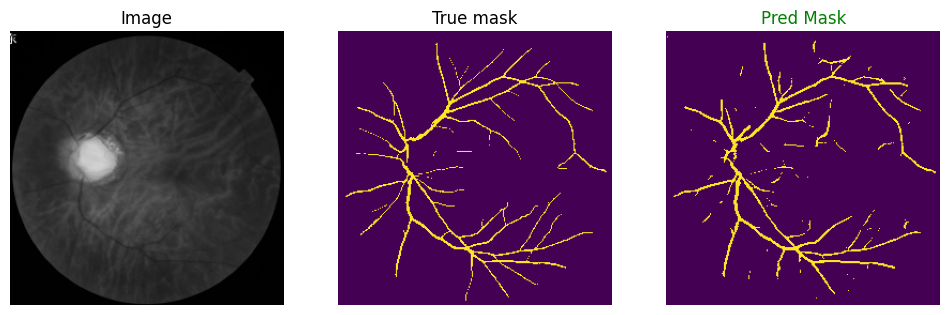

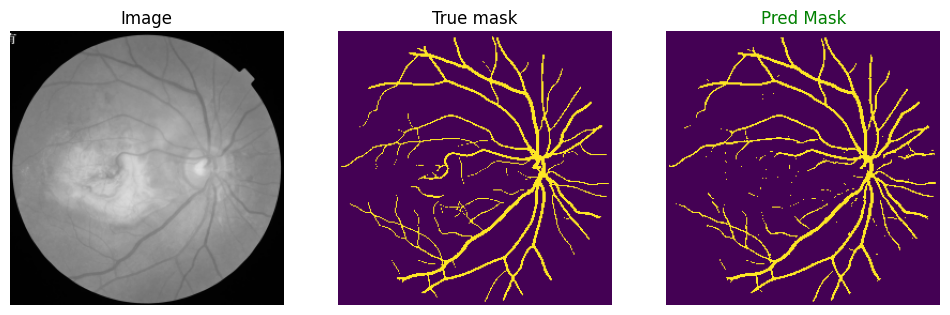

In [44]:
for i in range(5):
    plot(best_model,test_set[np.random.randint(0,len(test_set))],device)

**Score**

In [46]:
test_f1, test_recall, test_specificity, test_auroc,test_iou=eval_for_seg(best_model,test_loader,device)

print(f'f1 {test_f1}, recall {test_recall}, spe {test_specificity}, auc {test_auroc}, iou {test_iou}')

f1 0.8416129350662231, recall 0.844183623790741, spe 0.9875450730323792, auc 0.9158644080162048, iou 0.7265385985374451


**Show Feature map per encode layers**

In [69]:
def plot_feature_per_conv(sample,model):
    module_dict = {name: module for name, module in model.named_modules()
             if isinstance(module, (nn.Conv2d,nn.ReLU,nn.BatchNorm2d))}
    len_conv_dict = len({name: module for name, module in model.named_modules()
             if isinstance(module, (nn.Conv2d))})
    tmp=sample['image'].unsqueeze(0)
    i=0
    break_ = (len_conv_dict//2) + (len_conv_dict//2)%2
    break_ = break_ if break_ <=10 else 10
    fig,ax = plt.subplots(2,break_//2,figsize=(14,7))
    for module in module_dict.values():
        module.to('cpu')
        tmp=module(tmp.cpu())
        if isinstance(module,nn.Conv2d):
            ax[i//(break_//2),i%(break_//2)].imshow(torch.sigmoid(torch.max(tmp[0],0).values.detach().cpu())*255,cmap='gray')
            ax[i//(break_//2),i%(break_//2)].axis(False)
            ax[i//(break_//2),i%(break_//2)].set_title(f'Feature map in conv:{i}')
            i+=1
        if i==break_:break
    plt.show()

**Model chua duoc hoc**

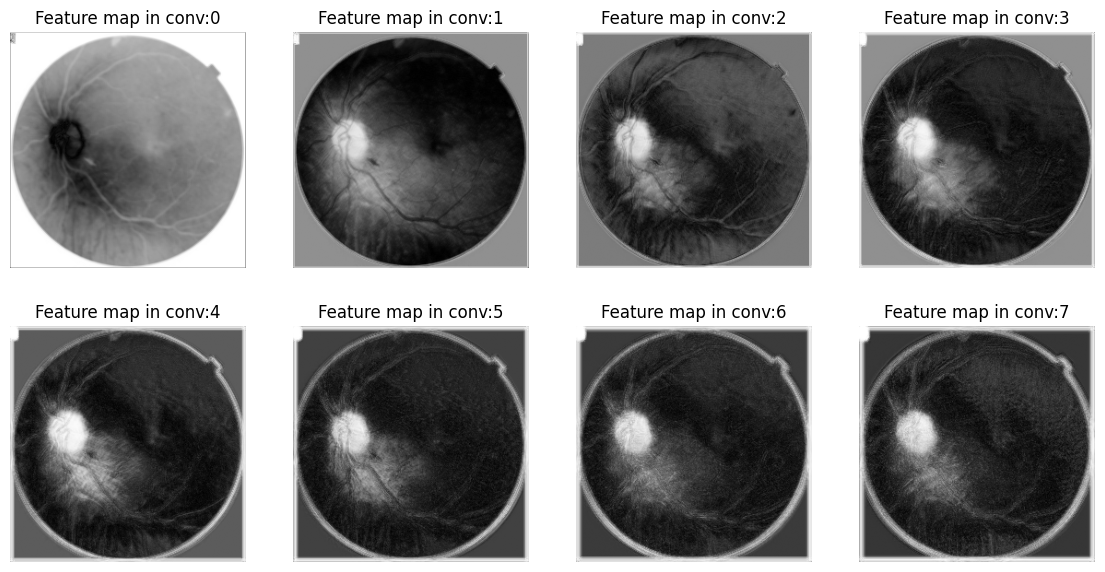

In [63]:
plot_feature_per_conv(test_set[0],nn.Sequential(UNETModel(3,1),nn.Sigmoid()))

**Model da duoc hoc**

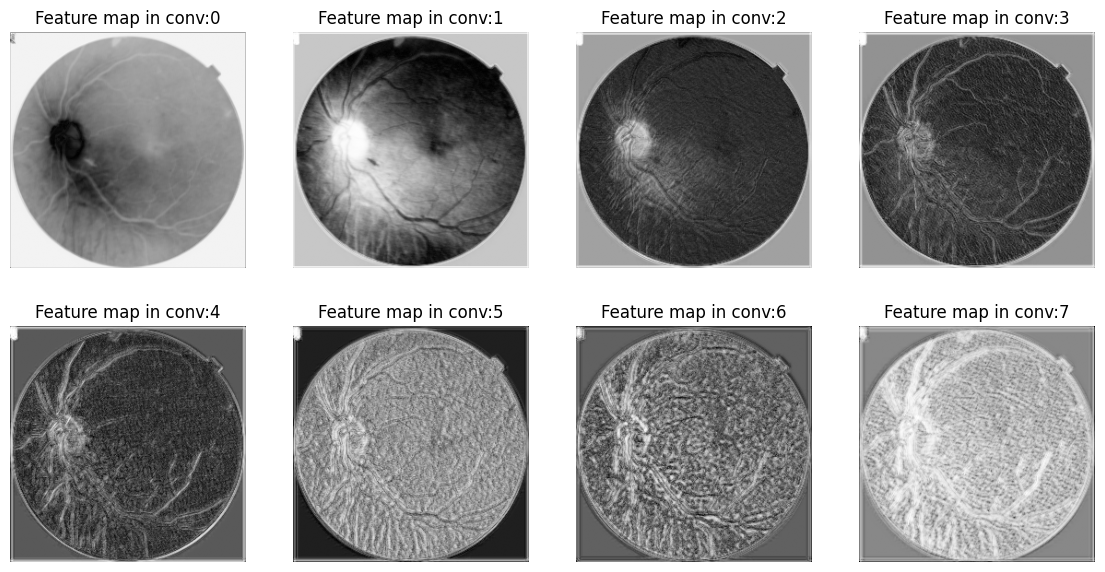

In [70]:
plot_feature_per_conv(test_set[0],best_model)

## UNET PP

In [65]:
best_model_pp=nn.Sequential(UNET_PP(3,1),nn.Sigmoid())
best_model_pp.load_state_dict(torch.load('/home/ubuntu/DuyPham/test_vton_1/notebooks/Duy/best_seg_model_pp.pth',weights_only=True))
best_model_pp.to(device)
best_model_pp=nn.DataParallel(best_model_pp,device_ids=[1,2,3,0])

In [68]:
test_f1, test_recall, test_specificity, test_auroc,test_iou=eval_for_seg(best_model_pp,test_loader,device)

print(f'f1 {test_f1}, recall {test_recall}, spe {test_specificity}, auc {test_auroc}, iou {test_iou}')

f1 0.8505121469497681, recall 0.8554593920707703, spe 0.9879874587059021, auc 0.9217234253883362, iou 0.7399052381515503


**Show random 5 image in test set**

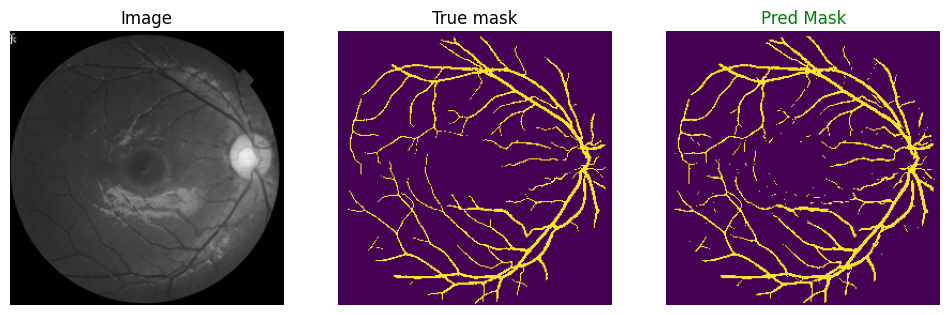

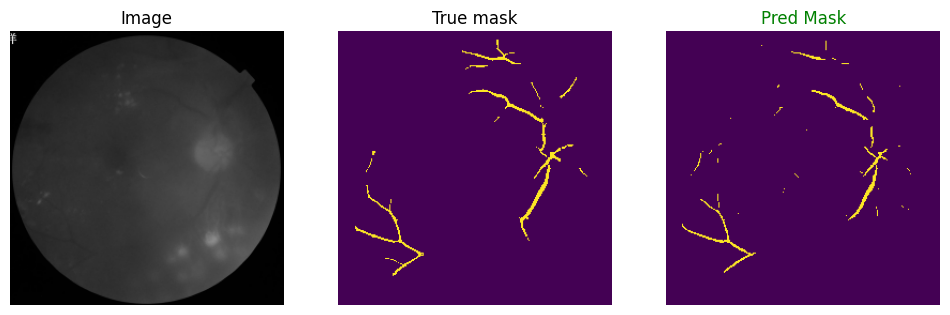

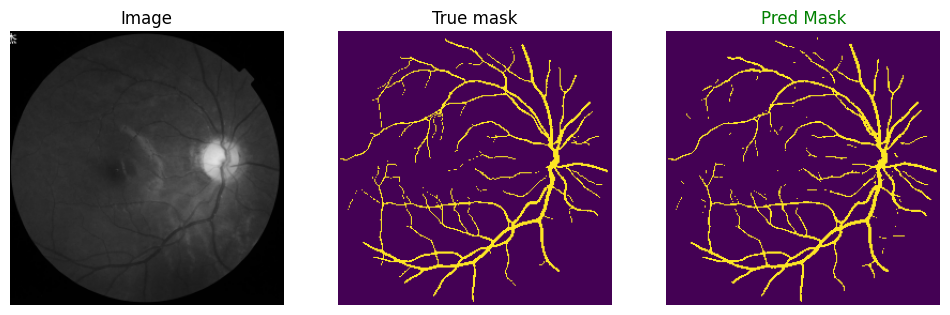

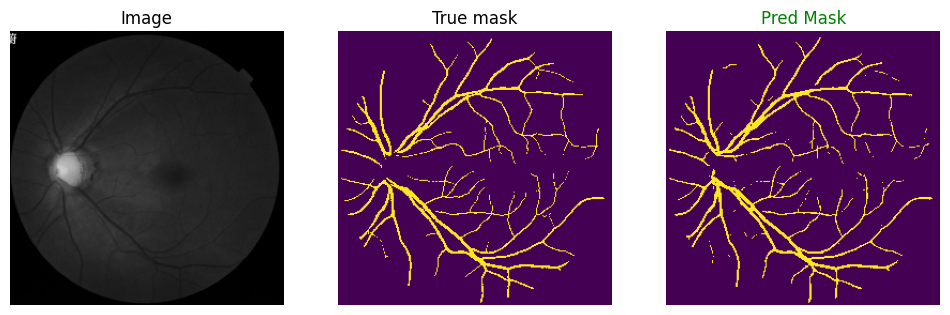

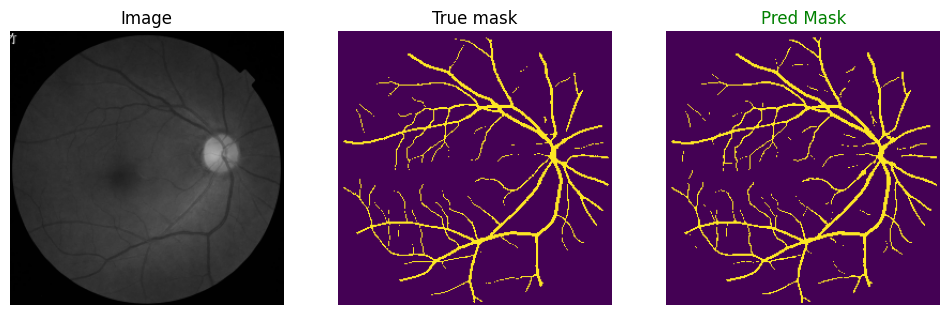

In [66]:
for i in range(5):
    plot(best_model_pp,test_set[np.random.randint(0,len(test_set))],device)

**Show feature cua model unet pp chua duoc hoc**

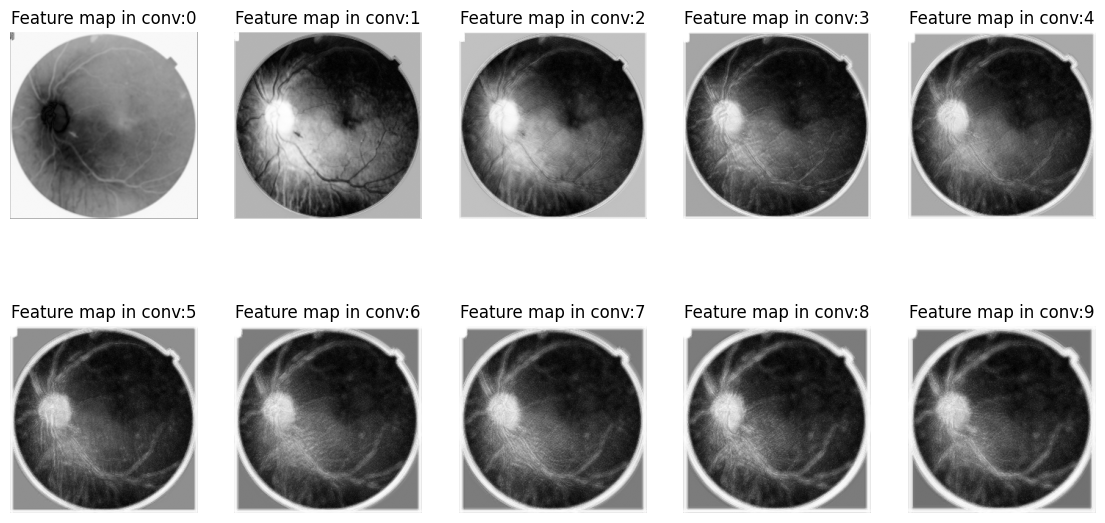

In [71]:
plot_feature_per_conv(test_set[0],nn.Sequential(UNET_PP(3,1),nn.Sigmoid()))

**Show feature cua model unet pp da duoc hoc**

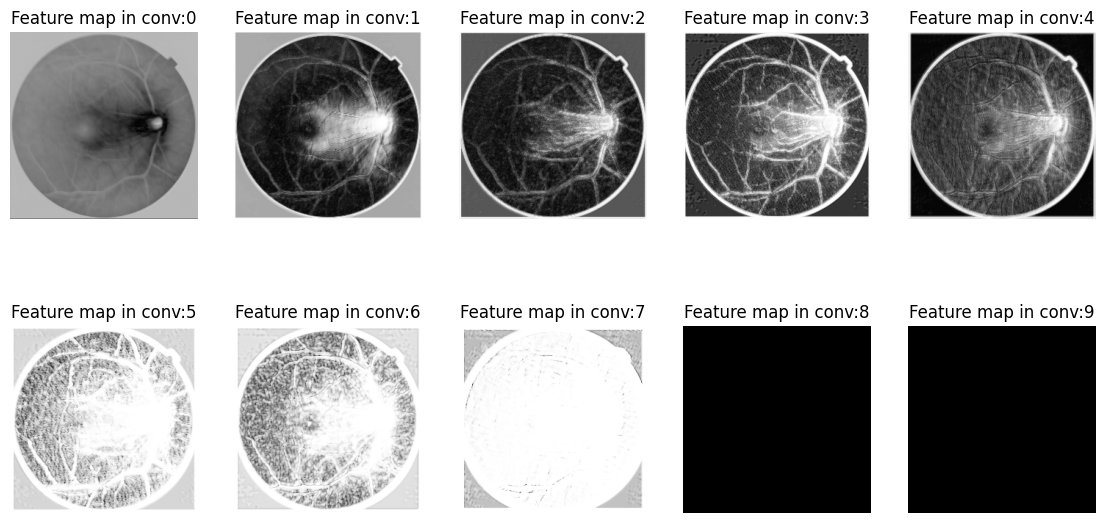

In [73]:
plot_feature_per_conv(train_set[0],best_model_pp)